# Titanic Survival Prediction: A Beginner's Guide 🚢

This notebook walks you through a complete machine learning project. We'll use Python and popular libraries to predict passenger survival on the Titanic.

### Step 1: Setting Up and Loading Data

First, we need to import the necessary libraries and load the data.

- `pandas`: A powerful library for data manipulation and analysis. We use it to load and handle our dataset.
- `seaborn` & `matplotlib`: Libraries for data visualization. They help us create plots and graphs to understand the data.
- `scikit-learn`: The most popular library for machine learning in Python. We'll use it for preprocessing, building our model, and evaluating it.

In [9]:
# Import necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
%matplotlib inline
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Load the dataset
# Seaborn has a built-in function to load the Titanic dataset
df = sns.load_dataset('titanic')

# Display the first 5 rows of the dataframe
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### Step 2: Exploratory Data Analysis (EDA)

EDA is about understanding your data before building a model. What are the columns? Are there missing values? How do different features relate to survival?

In [2]:
# Get a summary of the dataset (columns, data types, missing values)
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


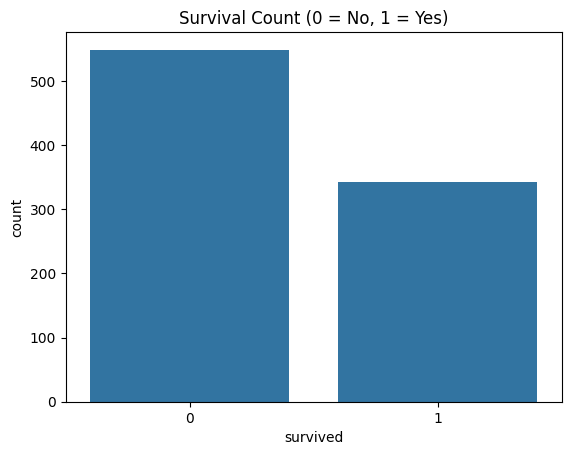

In [3]:
# Let's visualize the survival count
sns.countplot(x='survived', data=df)
plt.title('Survival Count (0 = No, 1 = Yes)')
plt.show()


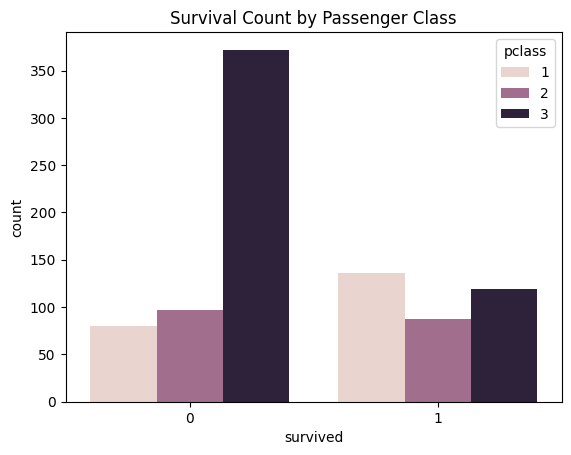

In [4]:
# How did survival vary by passenger class?
sns.countplot(x='survived', hue='pclass', data=df)
plt.title('Survival Count by Passenger Class')
plt.show()



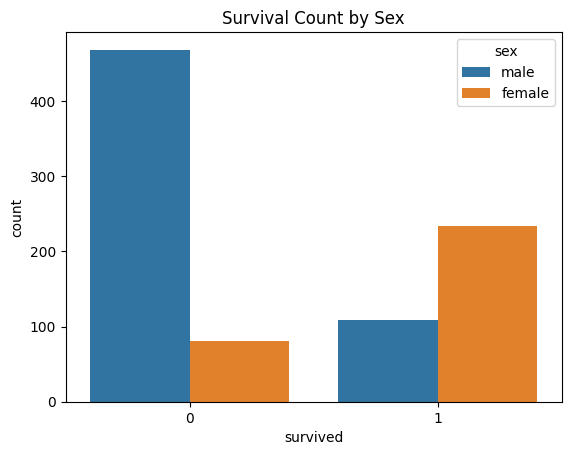

In [5]:
# How did survival vary by sex?
sns.countplot(x='survived', hue='sex', data=df)
plt.title('Survival Count by Sex')
plt.show()

**Observations from EDA:**
- More people died than survived.
- Passengers in the 1st class had a higher survival rate.
- Female passengers had a much higher survival rate than male passengers.

### Step 3: Data Preprocessing & Feature Engineering

Machine learning models need numbers to work, not text (like 'male' or 'female'). We also need to handle missing data.

1.  **Select Features:** We won't use all columns. Let's pick a few important ones.
2.  **Handle Missing Values:** The 'age' and 'embarked' columns have missing values. We'll fill the missing 'age' with the average age and 'embarked' with the most common port.
3.  **Convert Categorical Features:** We'll convert 'sex' and 'embarked' into numerical columns.

In [7]:
# Select features we want to use for our model
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
target = 'survived'

# Create a new dataframe with only our selected features and target
df_clean = df[features + [target]].copy()


In [10]:
# --- Data Cleaning ---

# 1. Fill missing 'age' values with the median age
df_clean['age'].fillna(df_clean['age'].median(), inplace=True)

# 2. Fill missing 'embarked' values with the most common value (mode)
df_clean['embarked'].fillna(df_clean['embarked'].mode()[0], inplace=True)

In [11]:
# --- Feature Conversion ---

# Convert 'sex' and 'embarked' into numerical columns using one-hot encoding
df_clean = pd.get_dummies(df_clean, columns=['sex', 'embarked'], drop_first=True)

In [12]:
# Display the cleaned data
df_clean.head()

,pclass,age,sibsp,parch,fare,survived,sex_male,embarked_Q,embarked_S
0,3,22.0,1,0,7.2500,0,True,False,True
1,1,38.0,1,0,71.2833,1,False,False,False
2,3,26.0,0,0,7.9250,1,False,False,True
3,1,35.0,1,0,53.1000,1,False,False,True
4,3,35.0,0,0,8.0500,0,True,False,True


### Step 4: Splitting the Data

We need to split our data into two parts:
- **Training set:** The model learns from this data (usually 80%).
- **Testing set:** We use this data to evaluate how well the model learned (usually 20%).

The `train_test_split` function from `scikit-learn` does this for us easily.

In [13]:
# Define our features (X) and target (y)
X = df_clean.drop('survived', axis=1)
y = df_clean['survived']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (712, 8)
Testing data shape: (179, 8)


### Step 5: Building and Training the Model

We'll use a **Random Forest Classifier**. Think of it as a group of decision trees that vote together to make a final prediction. It's a powerful and popular choice for beginners.

- **Instantiate:** Create an instance of the model.
- **Train:** Use the `.fit()` method on the training data (`X_train`, `y_train`) to train the model.

In [14]:
# Create the Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model using our training data
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Step 6: Evaluating the Model

Now let's see how our model performs on the unseen test data. We'll make predictions on `X_test` and compare them to the actual outcomes (`y_test`). **Accuracy** is a simple metric that tells us the percentage of correct predictions.

In [15]:
# Make predictions on the test data
y_pred = model.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.8212
